In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

I want to explore customer purchase patterns in the online fashion retail domain, inspired by platforms like SHEIN.

Since actual SHEIN data isn’t publicly available, I generated a realistic dataset with:
- 2,000 transactions representing customer shopping baskets
- 25 products, chosen to match Vietnam’s weather and current fashion trends

Each basket contains 1 to 6 randomly selected items, simulating typical SHEIN carts.

In [2]:
random.seed(911)
np.random.seed(911)

In [3]:
# Define 50 SHEIN-style fashion items
fashion_items = [
    "Crop Top", "Tank Top", "Sleeveless Dress", "Maxi Skirt", "Mini Skirt",
    "High-Waisted Shorts", "Linen Pants", "Oversized T-shirt", "Printed Blouse", "Denim Jacket",
    "Light Rain Jacket", "Windbreaker", "Summer Dress", "Ribbed Tee", "Off-Shoulder Top",
    "Wrap Dress", "Wide-Leg Pants", "Button-Up Shirt", "Co-ord Set", "Floral Blouse",
    "Ruffle Skirt", "Short Romper", "Pleated Skirt", "Sheer Blouse", "Bermuda Shorts"
    # "Canvas Tote Bag", "Bucket Hat", "Sunglasses", "Strappy Sandals", "Platform Shoes",
    # "Chunky Sneakers", "Ankle Boots", "Clear Umbrella", "Rain Boots", "Crossbody Bag",
    # "Straw Hat", "Crop Cardigan", "Tie-Dye Shirt", "Seamless Bra", "Bike Shorts",
    # "Layered Necklace", "Denim Shorts", "Chiffon Blouse", "Halter Neck Top", "Mesh Cover-up",
    # "Sun Hat", "Light Hoodie", "Silk Scarf", "Stud Earrings", "Cropped Blazer"
]

# Generate 2000 transactions
def generate_transaction(items, min_items=1, max_items=6):
    n_items = random.randint(min_items, max_items)
    return random.sample(items, n_items)

transactions = [generate_transaction(fashion_items) for _ in range(2000)]

In [4]:
transactions[:10]

[['Summer Dress', 'Pleated Skirt', 'Mini Skirt', 'High-Waisted Shorts'],
 ['Bermuda Shorts',
  'Oversized T-shirt',
  'Pleated Skirt',
  'Wrap Dress',
  'Short Romper'],
 ['Sleeveless Dress', 'Button-Up Shirt'],
 ['Linen Pants', 'Pleated Skirt', 'Mini Skirt', 'Ruffle Skirt'],
 ['Tank Top',
  'Denim Jacket',
  'Bermuda Shorts',
  'Maxi Skirt',
  'Summer Dress',
  'Printed Blouse'],
 ['Oversized T-shirt', 'Wide-Leg Pants', 'Printed Blouse'],
 ['Light Rain Jacket'],
 ['High-Waisted Shorts',
  'Off-Shoulder Top',
  'Short Romper',
  'Sleeveless Dress',
  'Ribbed Tee',
  'Denim Jacket'],
 ['Wrap Dress', 'Mini Skirt', 'Light Rain Jacket', 'Floral Blouse'],
 ['Summer Dress', 'Co-ord Set', 'Tank Top', 'Printed Blouse']]

In [5]:
# Convert to a DataFrame
df = pd.DataFrame({'Transaction': range(1, 2001), 'Items': transactions})
df.head()

,Transaction,Items
0,1,"[Summer Dress, Pleated Skirt, Mini Skirt, High..."
1,2,"[Bermuda Shorts, Oversized T-shirt, Pleated Sk..."
2,3,"[Sleeveless Dress, Button-Up Shirt]"
3,4,"[Linen Pants, Pleated Skirt, Mini Skirt, Ruffl..."
4,5,"[Tank Top, Denim Jacket, Bermuda Shorts, Maxi ..."


In [6]:
df.sample(5)

,Transaction,Items
1767,1768,[Ribbed Tee]
1506,1507,"[Off-Shoulder Top, Crop Top, Light Rain Jacket]"
1183,1184,"[Summer Dress, Crop Top, Printed Blouse, Overs..."
1761,1762,"[Linen Pants, Short Romper, Floral Blouse, Win..."
219,220,"[Ribbed Tee, Printed Blouse]"


# EDA

### **1. Basket Size Distribution (How many items per transaction?)**

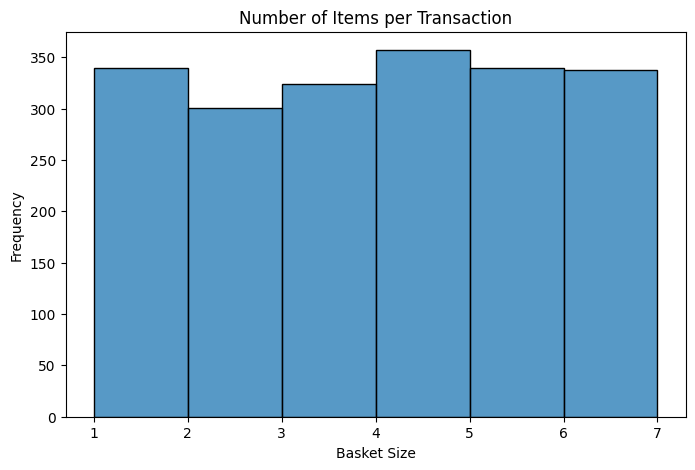

In [7]:
df['basket_size'] = df['Items'].apply(len)

plt.figure(figsize=(8, 5))
sns.histplot(df['basket_size'], bins=range(1, 8), kde=False)
plt.title("Number of Items per Transaction")
plt.xlabel("Basket Size")
plt.ylabel("Frequency")
plt.show()

### **2. Top-Selling Fashion Items**

In [8]:
# Flatten all items into one list
all_items = [item for sublist in df['Items'] for item in sublist]
item_counts = Counter(all_items)
top_items_df = pd.DataFrame(item_counts.items(), columns=["Item", "Count"]).sort_values("Count", ascending=False)
top_items_df.head()

,Item,Count
21,Co-ord Set,316
0,Summer Dress,308
10,Linen Pants,307
7,Short Romper,302
2,Mini Skirt,299


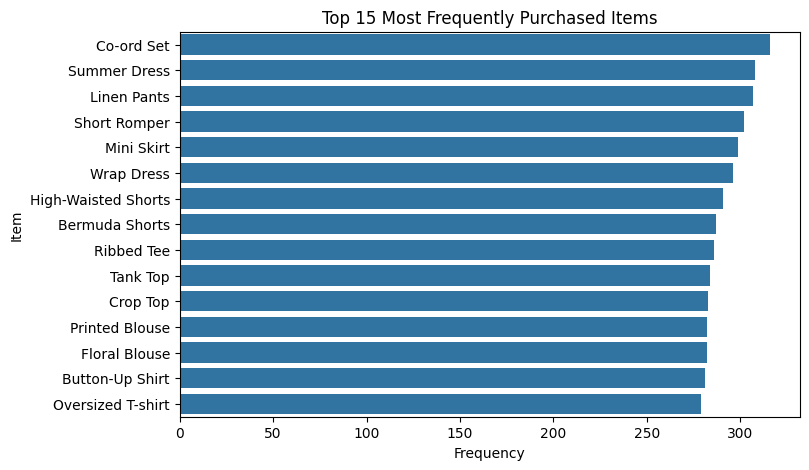

In [9]:
# Plot top 15
plt.figure(figsize=(8, 5))
sns.barplot(x="Count", y="Item", data=top_items_df.head(15))
plt.title("Top 15 Most Frequently Purchased Items")
plt.xlabel("Frequency")
plt.ylabel("Item")
plt.show()

# Data Normalization

In [10]:
te = TransactionEncoder()
te_array = te.fit(df['Items']).transform(df['Items'])

basket = pd.DataFrame(te_array, columns=te.columns_)
basket.head()

,Bermuda Shorts,Button-Up Shirt,Co-ord Set,Crop Top,Denim Jacket,Floral Blouse,High-Waisted Shorts,Light Rain Jacket,Linen Pants,Maxi Skirt,...,Ribbed Tee,Ruffle Skirt,Sheer Blouse,Short Romper,Sleeveless Dress,Summer Dress,Tank Top,Wide-Leg Pants,Windbreaker,Wrap Dress
0,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
4,True,False,False,False,True,False,False,False,False,True,...,False,False,False,False,False,True,True,False,False,False


# Running Apriori & Extracting Rules

The first step in order to create a set of association rules is to determine the optimal thresholds for support and lift/confidence. If we set these values too low, then the algorithm will take longer to execute and we will get a lot of rules (most of them will not be useful).

We can try different values of support and lift and see graphically how many rules are generated for each combination.

In [11]:
support_levels = [0.03, 0.025, 0.02]
lift_levels = [1.5, 1.4, 1.3, 1.2, 1.1]

# Dictionary to store number of rules per support level
rule_counts = {f'Support {float(s*100)}%': [] for s in support_levels}
rule_counts

{'Support 3.0%': [], 'Support 2.5%': [], 'Support 2.0%': []}

In [12]:
# Loop over each support level
for support in support_levels:
    # Generate frequent itemsets
    frequent_itemsets = apriori(basket, min_support=support, use_colnames=True)
    for lift in lift_levels:
        rules = association_rules(frequent_itemsets, metric="lift", min_threshold=lift)
        rule_counts[f'Support {float(support*100)}%'].append(len(rules))
rule_counts

{'Support 3.0%': [0, 0, 0, 0, 0],
 'Support 2.5%': [0, 0, 6, 20, 34],
 'Support 2.0%': [0, 0, 6, 32, 116]}

In [13]:
# Create a DataFrame for plotting
df_rules = pd.DataFrame(rule_counts)
df_rules['Lift'] = lift_levels

# Melt DataFrame for seaborn lineplot
df_melted = df_rules.melt(id_vars='Lift', var_name='Support Level', value_name='Rule Count')
df_melted.head(10)

,Lift,Support Level,Rule Count
0,1.5,Support 3.0%,0
1,1.4,Support 3.0%,0
2,1.3,Support 3.0%,0
3,1.2,Support 3.0%,0
4,1.1,Support 3.0%,0
5,1.5,Support 2.5%,0
6,1.4,Support 2.5%,0
7,1.3,Support 2.5%,6
8,1.2,Support 2.5%,20
9,1.1,Support 2.5%,34


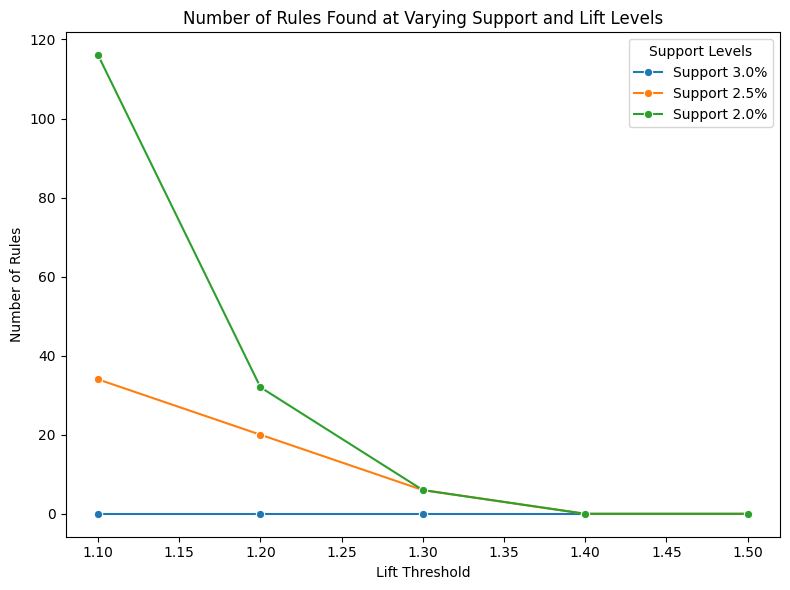

In [14]:
# Plot
plt.figure(figsize=(8, 6))
sns.lineplot(data=df_melted, x='Lift', y='Rule Count', hue='Support Level', marker='o')
plt.title('Number of Rules Found at Varying Support and Lift Levels')
plt.xlabel('Lift Threshold')
plt.ylabel('Number of Rules')
# plt.grid(True)
plt.legend(title='Support Levels')
plt.tight_layout()
plt.show()

- **Support level of 3%:** The number of rules is zero across all lift thresholds. This indicates that very few item combinations occur frequently enough (≥3%) to meet the minimum support. => This threshold is too strict for this dataset and results in no actionable rules.
- **Support level of 2.5%:** At a low lift threshold of 1.10, around >30 rules are generated. As the lift increases (to 1.20, 1.30...), the number of rules drops quickly. At a lift of 1.40 or above, no rules are found. => This support level allows a moderate number of rules to be discovered, but those with strong correlations (high lift) are limited.
- **Support level of 2%:** The highest number of rules appears at lift = 1.10, with over 115 rules. The rule count sharply declines as lift increases: About 32 rules at lift = 1.20, 6 rules at lift = 1.30, Almost zero by lift = 1.40 or higher. => This threshold captures the broadest range of associations, including weaker and stronger ones. It’s ideal for exploration, especially in highly varied datasets like fashion.

To balance rule quantity and business relevance, I will use: Support = 2.5% and Lift = 1.20. This combination ensures:
- Rules are generated from items that appear frequently enough to matter.
- The number of rules is manageable for analysis and action.
- Lift > 1.2 filters for stronger associations, ideal for: Curating product bundles, Designing cross-sell campaigns, Identifying co-purchased seasonal trends

In [15]:
# Run Apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(basket,
                            min_support=0.025,
                            use_colnames=True)

print(f"Found {len(frequent_itemsets)} frequent itemsets with support ≥ 2.5%")
frequent_itemsets.sort_values(by='support', ascending=False).head(10)

Found 44 frequent itemsets with support ≥ 2.5%


,support,itemsets
2,0.1580,(Co-ord Set)
20,0.1540,(Summer Dress)
8,0.1535,(Linen Pants)
18,0.1510,(Short Romper)
10,0.1495,(Mini Skirt)
24,0.1480,(Wrap Dress)
6,0.1455,(High-Waisted Shorts)
0,0.1435,(Bermuda Shorts)
15,0.1430,(Ribbed Tee)
21,0.1420,(Tank Top)


In [16]:
# Extract association rules from frequent itemsets
rules = association_rules(frequent_itemsets,
                          metric='lift',
                          min_threshold=1.2)

print(f"Extracted {len(rules)} rules with lift ≥ 1.2")
rules = rules.sort_values(by='lift', ascending=False)

Extracted 20 rules with lift ≥ 1.2


In [17]:
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

,antecedents,consequents,support,confidence,lift
8,(Denim Jacket),(Maxi Skirt),0.0260,0.191882,1.395505
9,(Maxi Skirt),(Denim Jacket),0.0260,0.189091,1.395505
0,(Maxi Skirt),(Bermuda Shorts),0.0270,0.196364,1.368388
1,(Bermuda Shorts),(Maxi Skirt),0.0270,0.188153,1.368388
14,(Printed Blouse),(Sleeveless Dress),0.0250,0.177305,1.313370
15,(Sleeveless Dress),(Printed Blouse),0.0250,0.185185,1.313370
19,(Short Romper),(Wide-Leg Pants),0.0255,0.168874,1.279350
18,(Wide-Leg Pants),(Short Romper),0.0255,0.193182,1.279350
13,(Short Romper),(High-Waisted Shorts),0.0275,0.182119,1.251678
12,(High-Waisted Shorts),(Short Romper),0.0275,0.189003,1.251678
